In [2]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
image = cv2.imread('./sample/img1.jpg')
image.shape

(1350, 1080, 3)

(1350, 1080, 3)

The above shows the y and x axis vales along with the BRG

1350 → height (rows, y-axis)

1080 → width (columns, x-axis)

3 → channels (color depth, i.e., RGB)

The valyes of x and y varies from 0 (Intense Black) to 255 (brightest) and under BRG

Channel 0 → Blue

Channel 1 → Green

Channel 2 → Red

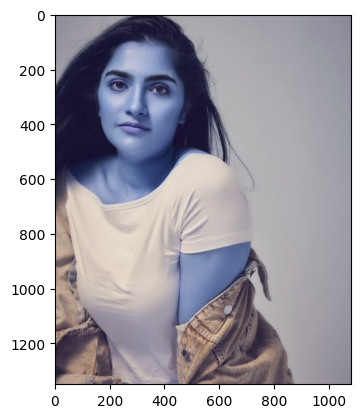

In [4]:
plt.imshow(image)

In [5]:
#Converting the color to drop off the BRG and to make the image with only gray tone
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray.shape

(1350, 1080)

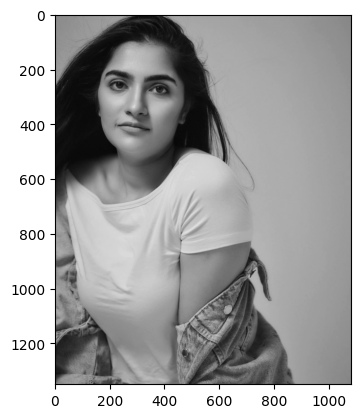

In [6]:
plt.imshow(gray, cmap='gray')

In [7]:
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

In [8]:
face = face_cascade.detectMultiScale(gray, 1.3, 5)
face

array([[110, 118, 382, 382]], dtype=int32)

In [9]:
(x, y, w, h) = face[0]
x, y, w, h

(np.int32(110), np.int32(118), np.int32(382), np.int32(382))

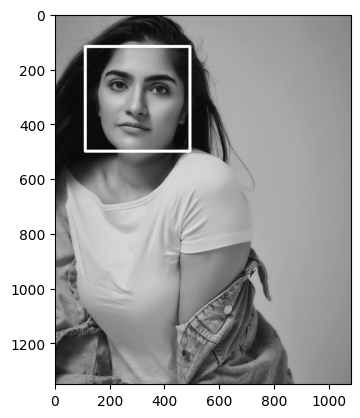

In [10]:
crop = cv2.rectangle(gray, (x, y),(x+w, y+h),(255,0,0),10) 
plt.imshow(crop, cmap='gray')

In [11]:
eyes = eye_cascade.detectMultiScale(gray, 1.3, 5)
eyes

array([[186, 219,  81,  81],
       [339, 237,  77,  77]], dtype=int32)

In [12]:
for (ex, ey, ew, eh) in eyes:
    cv2.rectangle(crop, (ex, ey),(ex+ew, ey+eh),(0,255,0),5)

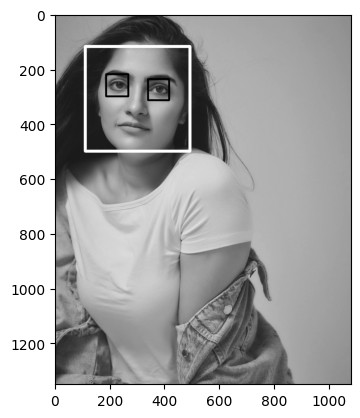

In [13]:
plt.imshow(crop, cmap='gray')

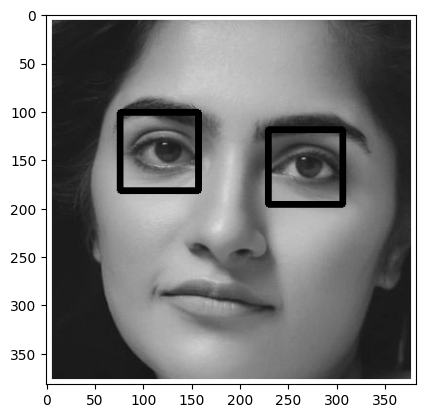

In [14]:
crop_img = gray[y:y+h, x:x+w]
plt.imshow(crop_img, cmap='gray')

In [15]:
#Writing a function to detec the face with two eyes in it and return the cropped image of the face
def get_face(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

    face = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in face:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = image[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes)>=2:
            return roi_color

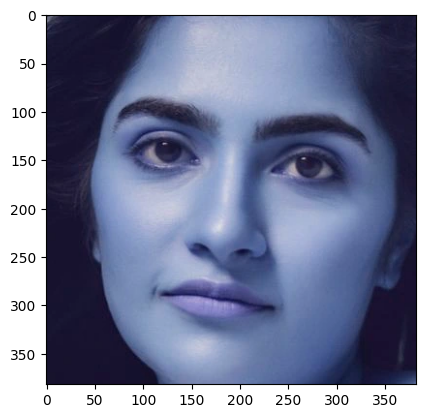

In [16]:
plt.imshow(get_face('./sample/img1.jpg'))

To Detect multiple faces in a single image use the below code

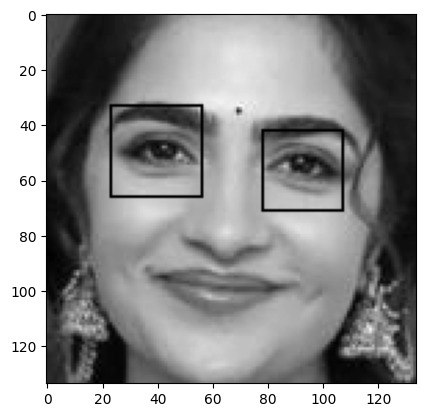

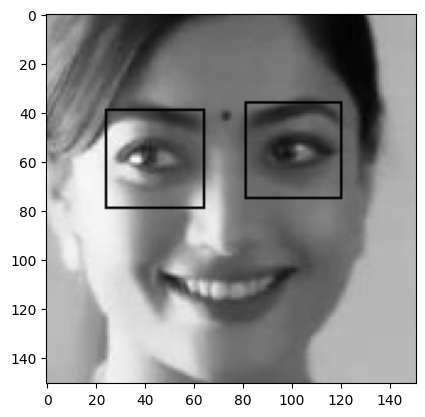

"\nplt.imshow(processed_faces[1], cmap='gray')\nplt.show()\n"

In [17]:
import cv2
import matplotlib.pyplot as plt

# Load cascades
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

#Use images img2 and img3
image = cv2.imread('./sample/img2.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Step 1: store cropped faces in a list
face_list = []
for (x, y, w, h) in faces:
    face_crop = gray[y:y+h, x:x+w]   # crop the face region
    face_list.append(face_crop)

# Step 2: loop through each face crop and detect eyes inside it
processed_faces = []
for face_crop in face_list:
    eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(face_crop, (ex, ey), (ex+ew, ey+eh), (0,255,0), 1)
    if len(eyes) >=2:
        processed_faces.append(face_crop)

#For showing all the processed faces with detected eyes
for i in range(len(processed_faces)):
    plt.imshow(processed_faces[i], cmap='gray')
    plt.show()

# Show the nth processed face
"""
plt.imshow(processed_faces[1], cmap='gray')
plt.show()
"""

To fetch the region of interest i.e face with two detectable eye which is cropped to the face region

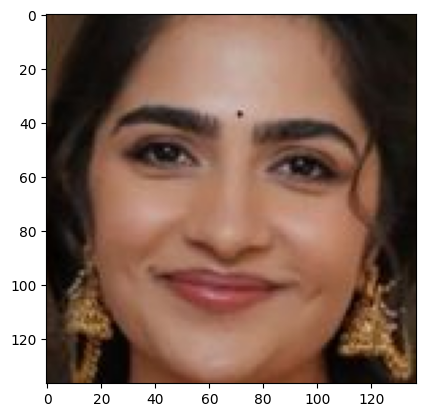

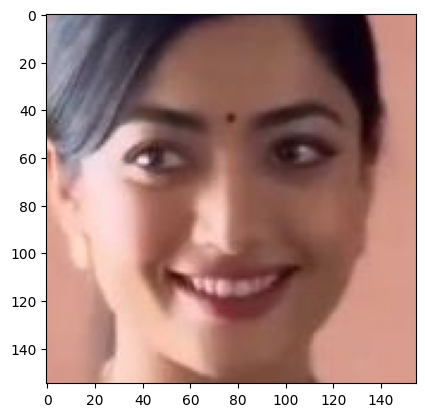

"\nplt.imshow(processed_faces[1], cmap='gray')\nplt.show()\n"

In [18]:
import cv2
import matplotlib.pyplot as plt

# Load cascades
face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

#Use images img2 and img3
image = plt.imread('./sample/img2.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Step 1: store cropped faces in a list
face_list = []
for (x, y, w, h) in faces:
    face_crop = image[y:y+h, x:x+w]   # crop the face region
    face_list.append(face_crop)

# Step 2: loop through each face crop and check if there are two visible eyes detected
processed_faces = []
for face_crop in face_list:
    eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
    if len(eyes) >=2:
        processed_faces.append(face_crop)

#For showing all the processed faces with detected eyes
for i in range(len(processed_faces)):
    plt.imshow(processed_faces[i], cmap='gray')
    plt.show()

# Show the nth processed face
"""
plt.imshow(processed_faces[1], cmap='gray')
plt.show()
"""

In [19]:
#Converting the above code into a function

import cv2
import matplotlib.pyplot as plt
%matplotlib inline

def get_face_multi(image_path):
    image = plt.imread(image_path)
    #Adding a check point to skip the files which return error when the file in not read by the module
    if image is None:
        print(f"⚠️ Skipping unreadable file: {image_path}")
        return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    face_list = []
    for (x, y, w, h) in faces:
        face_crop = image[y:y+h, x:x+w]
        face_list.append(face_crop)
    
    processed_faces = []
    for croppped_face in face_list:
        eyes = eye_cascade.detectMultiScale(croppped_face, 1.3, 5)
        if len(eyes)>=2:
            processed_faces.append(croppped_face)

    for i in range(len(processed_faces)):
        return processed_faces[i]

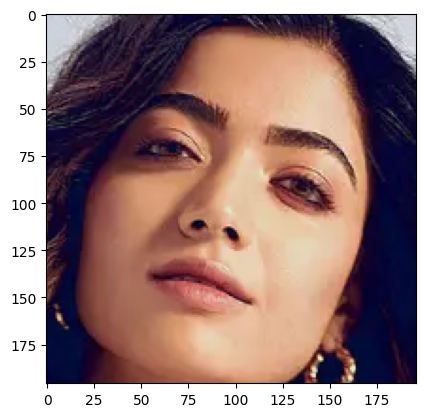

In [20]:
plt.imshow(get_face_multi('./sample/img3.jpg'))

Scanning the subfolders in the training images folder

In [21]:
path_to_data = "./Training_Images/"
path_to_cr_data = "./Crop_Images/"

In [22]:
import os
dir_name = []
for folder in os.scandir(path_to_data):
    if folder.is_dir():
        dir_name.append(folder.path)

In [23]:
dir_name

['./Training_Images/angelina_jolie',
 './Training_Images/darshan_thoogudeepa',
 './Training_Images/rukmini_vasanth',
 './Training_Images/tom_cruise',
 './Training_Images/will_smith']

Creating a folder to store the cropped images. Will clear the folder for each run

In [24]:
import shutil
import os
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [25]:
#Cropping single face in a image
#Writing a function to detec the face with two eyes in it and return the cropped image of the face
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    #Adding a check point to skip the files which return error when the file in not read by the module
    if img is None:
        #print(f"⚠️ Skipping unreadable file: {image_path}")
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
        return None

In [26]:
#Cropping multiple faces in a image
import cv2
import matplotlib.pyplot as plt
def get_face_multi(image_path):
    # Load cascades
    face_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('./haarcascades/haarcascade_eye.xml')

    image = cv2.imread(image_path)
    #Adding a check point to skip the files which return error when the file in not read by the module
    if image is None:
        #print(f"⚠️ Skipping unreadable file: {image_path}")
        return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Step 1: store cropped faces in a list
    face_list = []
    for (x, y, w, h) in faces:
        face_crop = image[y:y+h, x:x+w]   # crop the face region
        face_list.append(face_crop)

    # Step 2: loop through each face crop and detect eyes inside it
    processed_faces = []
    for face_crop in face_list:
        eyes = eye_cascade.detectMultiScale(face_crop, 1.3, 5)
        if len(eyes) >=2:
            processed_faces.append(face_crop)

    for i in range(len(processed_faces)):
        return processed_faces[i]

In [28]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in dir_name:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        if entry.is_file(): 
            roi_color = get_cropped_image_if_2_eyes(entry.path)
            if roi_color is not None:
                cropped_folder = path_to_cr_data + celebrity_name
                if not os.path.exists(cropped_folder):
                    os.makedirs(cropped_folder)
                    #cropped_image_dirs.append(cropped_folder)
                    print("Generating cropped images in folder: ",cropped_folder)
                    
                cropped_file_name = celebrity_name + str(count) + ".png"
                cropped_file_path = cropped_folder + "/" + cropped_file_name 
                
                cv2.imwrite(cropped_file_path, roi_color)
                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
                count += 1

angelina_jolie
darshan_thoogudeepa
rukmini_vasanth
tom_cruise
will_smith
Generating cropped images in folder:  ./Crop_Images/will_smith


Iterating the dictionary to show the cropped images for each celebrity

In [30]:
len(celebrity_file_names_dict['will_smith'])

37

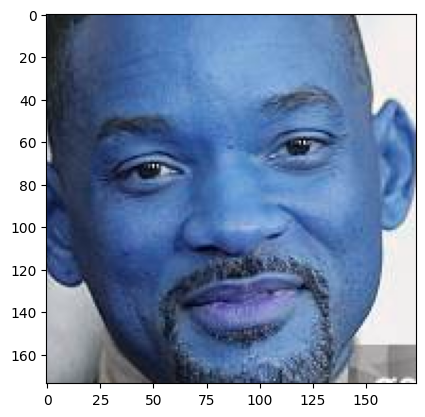

In [31]:
A = cv2.imread(celebrity_file_names_dict['will_smith'][0])
plt.imshow(A)

<h1>Wavelet Transformation <h1>

In [32]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

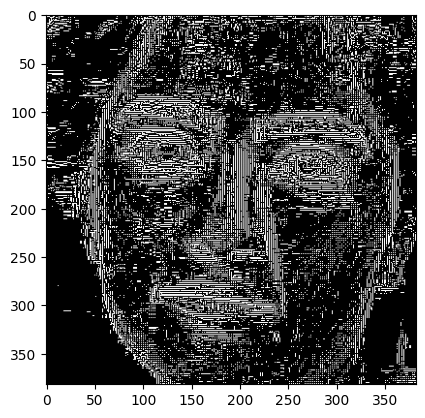

In [33]:
img_crop = get_face('./sample/img1.jpg')
plt.imshow(w2d(img_crop), cmap= 'gray')

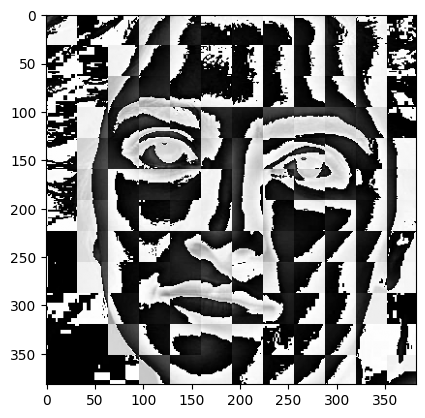

In [34]:
img_crop = get_face('./sample/img1.jpg')
plt.imshow(w2d(img_crop, 'db1',5), cmap= 'gray')

In [35]:
celeb_value_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    celeb_value_dict[celebrity_name] = count
    count += 1

In [36]:
celeb_value_dict

{'angelina_jolie': 0,
 'darshan_thoogudeepa': 1,
 'rukmini_vasanth': 2,
 'tom_cruise': 3,
 'will_smith': 4}

In [37]:
X = []
y = []
#Getting the Celebrity name and files belonging to the celibrity
for celebrity_name, training_file in celebrity_file_names_dict.items():
    #Iterating the images under the folder
    for training_image in training_file:
        img = cv2.imread(training_image)
        #Resizing the image to make all the image to llok uniform
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        #Wavelet Transformation of the image
        img_har = w2d(img,'db1',5)
        #Resing the transformed image
        scaled_img_har = cv2.resize(img_har, (32, 32))
        #Vertically stacking both resized images one below the other, so that model can use the features from both to determine the result
        combined_image = np.vstack((scalled_raw_img.reshape(32*32*3,1), scaled_img_har.reshape(32*32, 1)))
        X.append(combined_image)
        y.append(celeb_value_dict[celebrity_name])

In [38]:
X[0]

array([[ 34],
       [ 40],
       [ 63],
       ...,
       [  1],
       [  3],
       [247]], shape=(4096, 1), dtype=uint8)

In [39]:
len(X)

312

In [40]:
#Number of elements in a single element
len(X[0])

4096

In [41]:
32*32*3 + 32*32*1

4096

In [42]:
len(y)

312

In [43]:
#Shaping to look in the form of rows and columns 
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(312, 4096)

In [44]:
X[0]

array([ 34.,  40.,  63., ...,   1.,   3., 247.], shape=(4096,))

### Data cleaning process is done. Now we are ready to train our model

We will use SVM with rbf kernel tuned  with heuristic finetuning

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [55]:
print(len(X_train)/312)
print(len(y_test)/312)

0.75
0.25


In [73]:
pipe = Pipeline([('scale', StandardScaler()),('svc', SVC(kernel='linear', C=10))])
#{'rbf', 'poly', 'linear', 'sigmoid', 'precomputed'}
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.9102564102564102

In [74]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90        21
           1       1.00      0.86      0.92         7
           2       0.91      0.97      0.94        32
           3       0.82      0.88      0.85        16
           4       1.00      1.00      1.00         2

    accuracy                           0.91        78
   macro avg       0.94      0.91      0.92        78
weighted avg       0.91      0.91      0.91        78



In [75]:
celeb_value_dict

{'angelina_jolie': 0,
 'darshan_thoogudeepa': 1,
 'rukmini_vasanth': 2,
 'tom_cruise': 3,
 'will_smith': 4}

### Let's use GridSearch to try out different models with different paramets. Goal is to come up with best modle with best fine tuned parameters

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline

In [97]:
model_params = {
    'svm':{
        'model': SVC(gamma='auto',probability=True),
        'parameters': {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }
    },
    'randmonforest':{
        'model': RandomForestClassifier(),
        'parameters': {
            'randomforestclassifier__n_estimators': [1, 5, 10]
        }
    },
    'logisticregression':{
        'model': LogisticRegression(solver='liblinear',multi_class='auto'),
        'parameters':{
            'logisticregression__C': [1, 5, 10]
        }
    }
}

In [103]:
scores = []
best_estimator = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe, mp['parameters'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'Best_Score': clf.best_score_,
        'Best_parameter': clf.best_params_
    })
    best_estimator[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model', 'Best_Score', 'Best_parameter'])
df

c:\Users\Pradeep\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Pradeep\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Pradeep\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Pradeep\AppData\Local\Programs\

,model,Best_Score,Best_parameter
0,svm,0.820722,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,randmonforest,0.594357,{'randomforestclassifier__n_estimators': 10}
2,logisticregression,0.833302,{'logisticregression__C': 1}


In [101]:
best_estimator

{'svm': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('svc',
                  SVC(C=1, gamma='auto', kernel='linear', probability=True))]),
 'randmonforest': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestclassifier',
                  RandomForestClassifier(n_estimators=10))]),
 'logisticregression': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, multi_class='auto',
                                     solver='liblinear'))])}

In [104]:
best_estimator['svm'].score(X_test, y_test)

0.9102564102564102

In [105]:
best_estimator['logisticregression'].score(X_test, y_test)

0.8717948717948718

In [106]:
best_estimator['randmonforest'].score(X_test, y_test)

0.7051282051282052

In [107]:
best_clf = best_estimator['svm']

In [108]:
best_clf

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=1, gamma='auto', kernel='linear', probability=True))])

In [110]:
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[18,  0,  2,  1,  0],
       [ 0,  6,  0,  1,  0],
       [ 0,  0, 31,  1,  0],
       [ 1,  0,  1, 14,  0],
       [ 0,  0,  0,  0,  2]])

Text(95.72222222222221, 0.5, 'Actual')

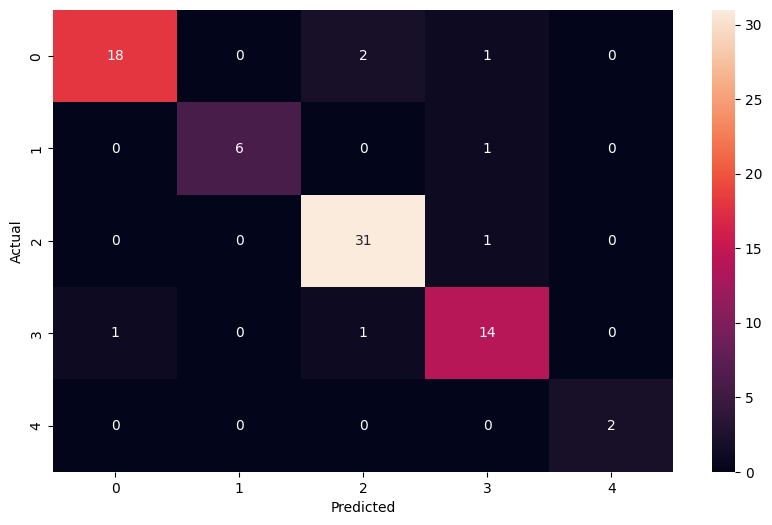

In [113]:
import seaborn as sn
plt.figure(figsize=(10,6))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [116]:
celeb_value_dict

{'angelina_jolie': 0,
 'darshan_thoogudeepa': 1,
 'rukmini_vasanth': 2,
 'tom_cruise': 3,
 'will_smith': 4}

In [115]:
import joblib
joblib.dump(best_clf, 'saved_model.pkl')

['saved_model.pkl']

In [118]:
import json
with open('class_dictionary.json', 'w') as f:
    f.write(json.dumps(celeb_value_dict))